# TA6 Analyser — Evaluation Results

This notebook is the single source of truth for every precision/recall/F1/CER/WER
number quoted in Chapter 6 of the dissertation. Every metric below is **computed by
running the actual pipeline code** in `ta6_analyser/scripts/` and `ta6_analyser/ta6/`
— nothing here is typed in by hand. Re-running this notebook top to bottom regenerates
every number and every figure from scratch.

**What this notebook does NOT cover** (still pending, see Chapter 6 discussion):
free-text cross-document NLI scored only against an offline lexical baseline
(F1 = 0.40, not a real language model), and no solicitor has yet reviewed pipeline
output for real-world correctness. Both are internal-validity results only.

Figures are saved to `figures/` at 300 dpi, ready to embed in the Word draft.


In [1]:
import os, sys, json
sys.path.insert(0, os.path.abspath(os.path.join("..")))  # ta6_analyser/
os.chdir(os.path.join(os.path.abspath(".."), "scripts"))  # scripts expect repo-relative paths (e.g. data/field_map.json)

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({"font.size": 11, "figure.dpi": 110, "savefig.dpi": 300})

FIG_DIR = os.path.join(os.path.dirname(os.getcwd()), "notebooks", "figures")
os.makedirs(FIG_DIR, exist_ok=True)

def savefig(fig, name):
    path = os.path.join(FIG_DIR, name)
    fig.savefig(path, bbox_inches="tight")
    print(f"saved {path}")

COLORS = {"tp": "#2e7d32", "fp": "#c62828", "fn": "#ef6c00", "bar": "#1f4e79", "bar2": "#5b9bd5"}
print("Setup complete.")


Setup complete.


## 1. Field-mapping coverage (System B, real 442-field template)

How much of the genuine Law Society 6th-edition fillable template
(`EDITABLE TA6 - 6th Edition 0426.pdf`, 442 AcroForm fields) the geometric field-mapper
(`ta6.groups` + `ta6.field_mapper`) can structurally resolve into answerable questions,
versus fields it leaves as unmatched "orphans". This is the basis for the 91% coverage
figure quoted in Chapter 5/6.


In [2]:
from scripts.generate_dataset_v2 import load_plan, DEFAULT_TEMPLATE

plan = load_plan(DEFAULT_TEMPLATE)
n_fields = plan["n_fields"]
n_orphans = len(plan["orphans"])
n_matched = n_fields - n_orphans
n_questions = len(plan["questions"])
coverage = n_matched / n_fields

print(f"Template fields total       : {n_fields}")
print(f"Discovered questions        : {n_questions}")
print(f"Fields reached by a question: {n_matched}")
print(f"Structural orphans          : {n_orphans}")
print(f"Field coverage              : {coverage:.1%}")


Template fields total       : 442
Discovered questions        : 143
Fields reached by a question: 404
Structural orphans          : 38
Field coverage              : 91.4%


saved /sessions/jolly-vigilant-archimedes/mnt/Dissertation/ta6_analyser/notebooks/figures/fig_6_1_field_coverage.png


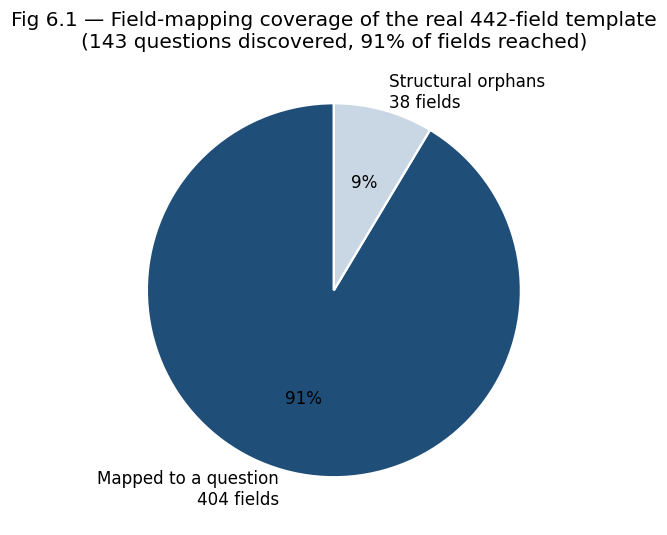

In [3]:
fig, ax = plt.subplots(figsize=(5, 5))
sizes = [n_matched, n_orphans]
labels = [f"Mapped to a question\n{n_matched} fields", f"Structural orphans\n{n_orphans} fields"]
ax.pie(sizes, labels=labels, autopct=lambda p: f"{p:.0f}%", startangle=90,
       colors=[COLORS["bar"], "#c9d6e3"], wedgeprops={"edgecolor": "white", "linewidth": 1.5})
ax.set_title(f"Fig 6.1 — Field-mapping coverage of the real 442-field template\n"
             f"({n_questions} questions discovered, {coverage:.0%} of fields reached)")
plt.tight_layout()
savefig(fig, "fig_6_1_field_coverage.png")
plt.show()


## 2. Structured-detection evaluation — hand-designed schema (System A)

`scripts/evaluate.py` scored against `pipeline/synth_eval/` — 60 synthetic records with
faults injected by construction (so ground truth is exact), run through the real rule
engine (`ta6.pipeline.analyse`). This is the simple hand-designed 3-field schema, not
the full 442-field template (see Section 3 for that).


In [4]:
from scripts.evaluate import run_eval

synth_dir = os.path.join("..", "..", "pipeline", "synth_eval")
r1 = run_eval(synth_dir, quiet=True)
print(f"Records: {r1['n_records']} ({r1['n_faulted']} faulted, {r1['n_clean']} clean)")
print(f"TP={r1['tp']}  FP={r1['fp']}  FN={r1['fn']}")
print(f"Precision={r1['precision']:.3f}  Recall={r1['recall']:.3f}  F1={r1['f1']:.3f}")
r1["per_type"]


Records: 60 (45 faulted, 15 clean)
TP=45  FP=0  FN=0
Precision=1.000  Recall=1.000  F1=1.000


{'cross_doc_contradiction': {'tp': 21,
  'fp': 0,
  'fn': 0,
  'precision': 1.0,
  'recall': 1.0},
 'missing_detail': {'tp': 16,
  'fp': 0,
  'fn': 0,
  'precision': 1.0,
  'recall': 1.0},
 'missing_attachment': {'tp': 8,
  'fp': 0,
  'fn': 0,
  'precision': 1.0,
  'recall': 1.0}}

saved /sessions/jolly-vigilant-archimedes/mnt/Dissertation/ta6_analyser/notebooks/figures/fig_6_2_system_a_prf1.png


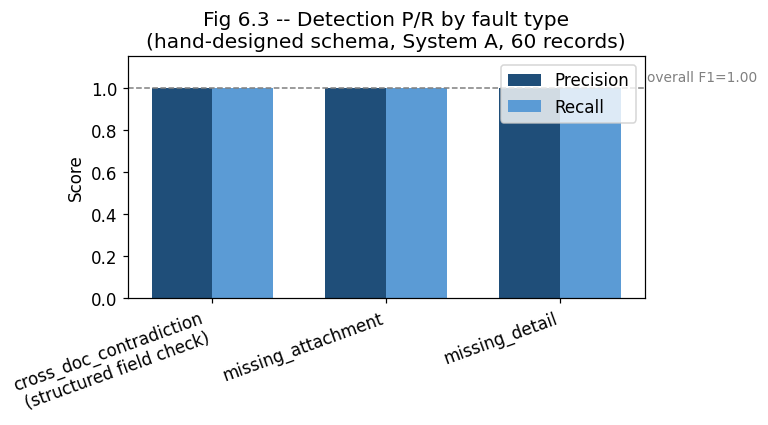

In [5]:
def plot_prf1(results_by_type, title, fname, overall=None, label_map=None):
    types = sorted(results_by_type.keys())
    prec = [results_by_type[t]["precision"] for t in types]
    rec = [results_by_type[t]["recall"] for t in types]
    x = range(len(types))
    fig, ax = plt.subplots(figsize=(7, 4))
    w = 0.35
    ax.bar([i - w/2 for i in x], prec, width=w, label="Precision", color=COLORS["bar"])
    ax.bar([i + w/2 for i in x], rec, width=w, label="Recall", color=COLORS["bar2"])
    ax.set_xticks(list(x))
    display_labels = [(label_map or {}).get(t, t) for t in types]
    ax.set_xticklabels(display_labels, rotation=20, ha="right")
    ax.set_ylim(0, 1.15); ax.set_ylabel("Score")
    ax.set_title(title)
    ax.legend(loc="upper right")
    if overall:
        ax.axhline(overall, color="grey", linestyle="--", linewidth=1)
        ax.text(len(types)-0.5, overall+0.03, f"overall F1={overall:.2f}", fontsize=9, color="grey")
    plt.tight_layout()
    savefig(fig, fname)
    plt.show()

# 12 Aug 2026 (dissertation audit Goal B3): cross_doc_contradiction here is a
# DETERMINISTIC structured cross-check against a matched planning record
# (ta6.pipeline / ta6.generator) -- it shares an issue-type NAME with, but not
# a MECHANISM with, the LLM-backed NLI stage scored in section 6.6. Relabelled
# on the x-axis so a reader cannot mistake this bar's P/R=1.00 for the same
# measurement as section 6.6's NLI result.
SYSTEM_A_LABELS = {"cross_doc_contradiction": "cross_doc_contradiction\n(structured field check)"}

plot_prf1(r1["per_type"], f"Fig 6.3 -- Detection P/R by fault type\n(hand-designed schema, System A, {r1['n_records']} records)",
           "fig_6_2_system_a_prf1.png", overall=r1["f1"], label_map=SYSTEM_A_LABELS)


## 3. Full-loop detection evaluation — real 442-field template (System B)

`scripts/evaluate_v2.py`: generate → fill the **real** template → write a PDF →
read the AcroForm back → run a generalised detection rule → score against the
manifest. This is the harder, realistic test: detection runs on values read back
from an actual filled PDF, not on the generator's own ground truth.


In [6]:
from scripts.evaluate_v2 import run_eval_v2

r2 = run_eval_v2(n=101, seed=1, quiet=True)
print(f"Forms: {r2['n_forms']} ({r2['n_forms_with_fault']} with >=1 fault)")
print(f"Fields: {r2['n_fields']}  Questions: {r2['n_questions']}  Orphans: {r2['n_orphans']}")
print(f"TP={r2['tp']}  FP={r2['fp']}  FN={r2['fn']}")
print(f"Precision={r2['precision']:.3f}  Recall={r2['recall']:.3f}  F1={r2['f1']:.3f}")
print(f"PDF fields the filler could not match: {r2['n_pdf_write_issues']} form(s)")
r2["per_type"]


Forms: 101 (47 with >=1 fault)
Fields: 442  Questions: 143  Orphans: 38
TP=57  FP=1  FN=1
Precision=0.983  Recall=0.983  F1=0.983
PDF fields the filler could not match: 0 form(s)


{'unanswered': {'tp': 35, 'fp': 0, 'fn': 0, 'precision': 1.0, 'recall': 1.0},
 'missing_detail': {'tp': 22,
  'fp': 1,
  'fn': 1,
  'precision': 0.9565217391304348,
  'recall': 0.9565217391304348}}

saved /sessions/jolly-vigilant-archimedes/mnt/Dissertation/ta6_analyser/notebooks/figures/fig_6_3_system_b_prf1.png


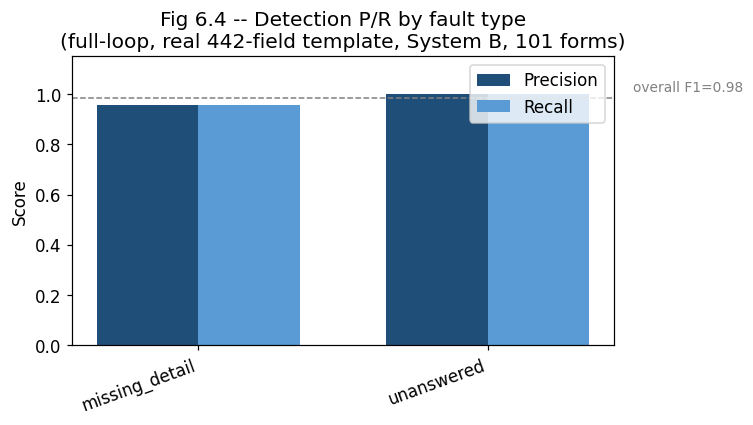

In [7]:
plot_prf1(r2["per_type"], f"Fig 6.4 -- Detection P/R by fault type\n(full-loop, real 442-field template, System B, {r2['n_forms']} forms)",
           "fig_6_3_system_b_prf1.png", overall=r2["f1"])


saved /sessions/jolly-vigilant-archimedes/mnt/Dissertation/ta6_analyser/notebooks/figures/fig_6_4_systemA_vs_systemB_f1.png


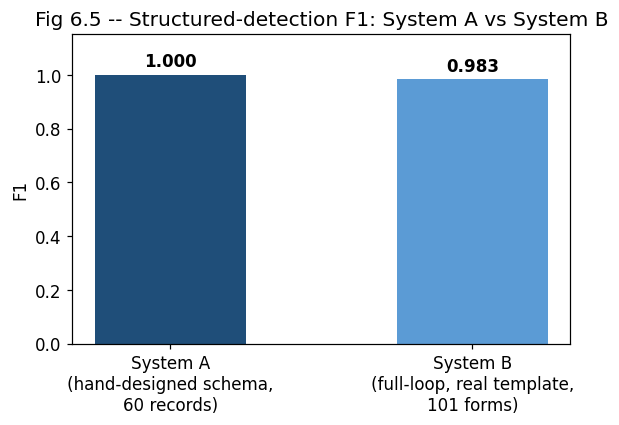

In [8]:
# Side-by-side: hand-designed schema vs full-loop real-template -- the headline
# comparison for Chapter 6 (structured detection validity across both systems).
fig, ax = plt.subplots(figsize=(5.5, 4))
labels = [f"System A\n(hand-designed schema,\n{r1['n_records']} records)",
          f"System B\n(full-loop, real template,\n{r2['n_forms']} forms)"]
f1s = [r1["f1"], r2["f1"]]
bars = ax.bar(labels, f1s, color=[COLORS["bar"], COLORS["bar2"]], width=0.5)
ax.set_ylim(0, 1.15); ax.set_ylabel("F1")
ax.set_title("Fig 6.5 -- Structured-detection F1: System A vs System B")
for b, v in zip(bars, f1s):
    ax.text(b.get_x()+b.get_width()/2, v+0.03, f"{v:.3f}", ha="center", fontweight="bold")
plt.tight_layout()
savefig(fig, "fig_6_4_systemA_vs_systemB_f1.png")
plt.show()


## 4. Digital vs scanned (OCR) — extraction and detection in the loop

`scripts/eval_ocr_vs_digital.py`: renders Section 4 forms in the real TA6 wording,
produces both a clean digital PDF and a degraded scanned version (lower DPI, blur,
skew, JPEG compression, run through Tesseract), and runs the real pipeline on both.
Reports detection P/R/F1 **and** extraction accuracy per route.


In [9]:
from scripts.eval_ocr_vs_digital import run as run_ocr_vs_digital

r3 = run_ocr_vs_digital(n=25, seed=7, quiet=True)
for track, s in r3.items():
    print(f"{track:<10} P={s['precision']:.2f} R={s['recall']:.2f} F1={s['f1']:.2f} "
          f"extract_acc={s['extract_acc']:.0%}")
r3


digital    P=1.00 R=1.00 F1=1.00 extract_acc=100%
scanned    P=1.00 R=1.00 F1=1.00 extract_acc=100%


{'digital': {'precision': 1.0,
  'recall': 1.0,
  'f1': 1.0,
  'extract_acc': 1.0,
  'tp': 9,
  'fp': 0,
  'fn': 0,
  'tn': 16,
  'ex_ok': 25},
 'scanned': {'precision': 1.0,
  'recall': 1.0,
  'f1': 1.0,
  'extract_acc': 1.0,
  'tp': 9,
  'fp': 0,
  'fn': 0,
  'tn': 16,
  'ex_ok': 25}}

saved /sessions/jolly-vigilant-archimedes/mnt/Dissertation/ta6_analyser/notebooks/figures/fig_6_5_digital_vs_scanned.png


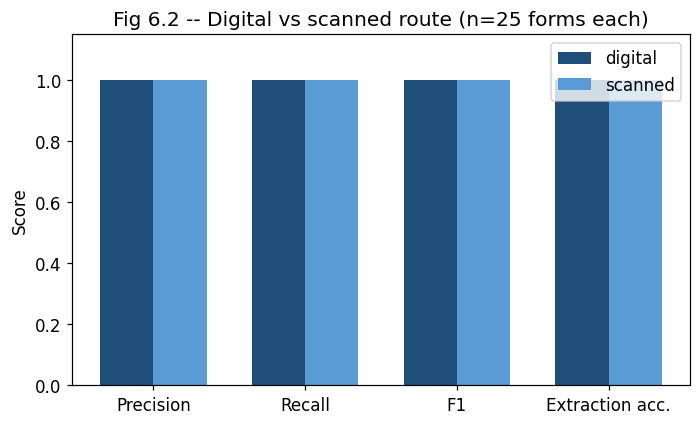

In [10]:
fig, ax = plt.subplots(figsize=(6.5, 4))
tracks = list(r3.keys())
metrics = ["precision", "recall", "f1", "extract_acc"]
metric_labels = ["Precision", "Recall", "F1", "Extraction acc."]
x = range(len(metrics))
w = 0.35
for i, track in enumerate(tracks):
    vals = [r3[track][m] for m in metrics]
    ax.bar([xi + (i - 0.5) * w for xi in x], vals, width=w, label=track,
           color=COLORS["bar"] if track == "digital" else COLORS["bar2"])
ax.set_xticks(list(x)); ax.set_xticklabels(metric_labels)
ax.set_ylim(0, 1.15); ax.set_ylabel("Score")
ax.set_title(f"Fig 6.2 -- Digital vs scanned route (n={r3[tracks[0]].get('tp',0)+r3[tracks[0]].get('fp',0)+r3[tracks[0]].get('fn',0)+r3[tracks[0]].get('tn',0)} forms each)")
ax.legend()
plt.tight_layout()
savefig(fig, "fig_6_5_digital_vs_scanned.png")
plt.show()


## 5. OCR error decomposition — CER/WER and failure attribution

`scripts/eval_ocr_error_decomposition.py` decomposes end-to-end failures on the
scanned route into three possible causes: (1) Tesseract misreading characters
(an OCR problem), (2) the regex parser failing to anchor a largely-correct OCR
transcription (a parsing problem), (3) the rule engine misjudging a correctly
extracted record. Character/word error rate is measured against the *exact*
known ground-truth text (not a proxy) via Levenshtein alignment.

This is also where the real bug found and fixed on 11 Aug 2026 is documented:
a leading-marker exclusion regex in `ta6.pipeline._parse_section4` was
mis-anchored, so a single OCR misread of "(b)" as "(o)" let the printed
instruction line through as if it were the seller's own answer. Every
`PARSER_FAILURE` case in this bucket, pre-fix, traced to that one bug.


In [11]:
from scripts.eval_ocr_error_decomposition import run as run_ocr_decomp

r4 = run_ocr_decomp(n=25, seed=7, quiet=True)
print(f"Mean CER (works-present forms): {r4['mean_cer']:.1%}")
print(f"Mean WER (works-present forms): {r4['mean_wer']:.1%}")
print(f"Failure attribution: {r4['buckets']}")


Mean CER (works-present forms): 9.6%
Mean WER (works-present forms): 25.3%
Failure attribution: {'CLEAN': 25}


saved /sessions/jolly-vigilant-archimedes/mnt/Dissertation/ta6_analyser/notebooks/figures/fig_6_6_ocr_error_decomposition.png


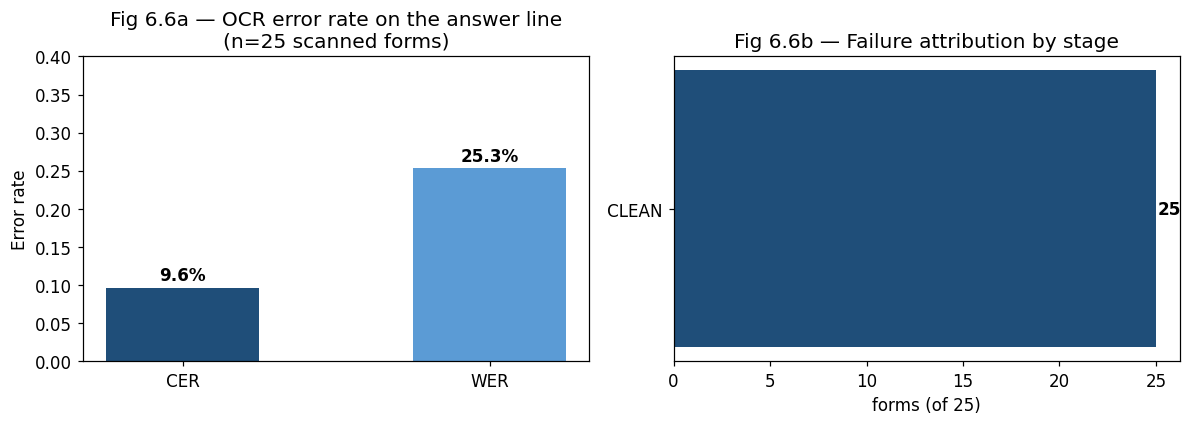

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# CER/WER
ax = axes[0]
vals = [r4["mean_cer"], r4["mean_wer"]]
bars = ax.bar(["CER", "WER"], vals, color=[COLORS["bar"], COLORS["bar2"]], width=0.5)
ax.set_ylim(0, max(0.4, max(vals) * 1.3)); ax.set_ylabel("Error rate")
ax.set_title(f"Fig 6.6a — OCR error rate on the answer line\n(n={r4['n']} scanned forms)")
for b, v in zip(bars, vals):
    ax.text(b.get_x()+b.get_width()/2, v+0.01, f"{v:.1%}", ha="center", fontweight="bold")

# failure attribution
ax = axes[1]
buckets = r4["buckets"]
names = list(buckets.keys())
counts = [buckets[n] for n in names]
ax.barh(names, counts, color=COLORS["bar"])
ax.set_xlabel(f"forms (of {r4['n']})")
ax.set_title("Fig 6.6b — Failure attribution by stage")
for i, c in enumerate(counts):
    ax.text(c + 0.1, i, str(c), va="center", fontweight="bold")

plt.tight_layout()
savefig(fig, "fig_6_6_ocr_error_decomposition.png")
plt.show()


## 6. Results summary (for Chapter 6 / Appendix)

One table pulling every headline metric computed above into a single place —
this is the table to paste (or screenshot) directly into the dissertation.
Regenerate this notebook before submission so the numbers in the write-up and
the numbers here cannot drift apart.


In [13]:
import pandas as pd

summary = pd.DataFrame([
    {"Evaluation": "Field-mapping coverage (System B, real template)",
     "Metric": "Coverage", "Value": f"{coverage:.1%}", "n": n_fields,
     "Script": "generate_dataset_v2.load_plan"},
    {"Evaluation": "Structured detection — hand-designed schema (System A)",
     "Metric": "F1", "Value": f"{r1['f1']:.3f}", "n": r1["n_records"],
     "Script": "evaluate.py"},
    {"Evaluation": "Structured detection — hand-designed schema (System A)",
     "Metric": "Precision", "Value": f"{r1['precision']:.3f}", "n": r1["n_records"],
     "Script": "evaluate.py"},
    {"Evaluation": "Structured detection — hand-designed schema (System A)",
     "Metric": "Recall", "Value": f"{r1['recall']:.3f}", "n": r1["n_records"],
     "Script": "evaluate.py"},
    {"Evaluation": "Structured detection — full-loop real template (System B)",
     "Metric": "F1", "Value": f"{r2['f1']:.3f}", "n": r2["n_forms"],
     "Script": "evaluate_v2.py"},
    {"Evaluation": "Structured detection — full-loop real template (System B)",
     "Metric": "Precision", "Value": f"{r2['precision']:.3f}", "n": r2["n_forms"],
     "Script": "evaluate_v2.py"},
    {"Evaluation": "Structured detection — full-loop real template (System B)",
     "Metric": "Recall", "Value": f"{r2['recall']:.3f}", "n": r2["n_forms"],
     "Script": "evaluate_v2.py"},
    {"Evaluation": "Digital route — detection", "Metric": "F1",
     "Value": f"{r3['digital']['f1']:.3f}",
     "n": r3['digital']['tp']+r3['digital']['fp']+r3['digital']['fn']+r3['digital']['tn'],
     "Script": "eval_ocr_vs_digital.py"},
    {"Evaluation": "Scanned/OCR route — detection", "Metric": "F1",
     "Value": f"{r3['scanned']['f1']:.3f}",
     "n": r3['scanned']['tp']+r3['scanned']['fp']+r3['scanned']['fn']+r3['scanned']['tn'],
     "Script": "eval_ocr_vs_digital.py"},
    {"Evaluation": "Digital route — extraction accuracy", "Metric": "Accuracy",
     "Value": f"{r3['digital']['extract_acc']:.1%}",
     "n": r3['digital']['tp']+r3['digital']['fp']+r3['digital']['fn']+r3['digital']['tn'],
     "Script": "eval_ocr_vs_digital.py"},
    {"Evaluation": "Scanned/OCR route — extraction accuracy", "Metric": "Accuracy",
     "Value": f"{r3['scanned']['extract_acc']:.1%}",
     "n": r3['scanned']['tp']+r3['scanned']['fp']+r3['scanned']['fn']+r3['scanned']['tn'],
     "Script": "eval_ocr_vs_digital.py"},
    {"Evaluation": "OCR error rate on answer line", "Metric": "Mean CER",
     "Value": f"{r4['mean_cer']:.1%}", "n": r4["n"], "Script": "eval_ocr_error_decomposition.py"},
    {"Evaluation": "OCR error rate on answer line", "Metric": "Mean WER",
     "Value": f"{r4['mean_wer']:.1%}", "n": r4["n"], "Script": "eval_ocr_error_decomposition.py"},
])
csv_path = os.path.join(FIG_DIR, "..", "results_summary.csv")
summary.to_csv(csv_path, index=False)
print(f"saved {os.path.abspath(csv_path)}")
summary


saved /sessions/jolly-vigilant-archimedes/mnt/Dissertation/ta6_analyser/notebooks/results_summary.csv


,Evaluation,Metric,Value,n,Script
0,"Field-mapping coverage (System B, real template)",Coverage,91.4%,442,generate_dataset_v2.load_plan
1,Structured detection — hand-designed schema (S...,F1,1.000,60,evaluate.py
2,Structured detection — hand-designed schema (S...,Precision,1.000,60,evaluate.py
3,Structured detection — hand-designed schema (S...,Recall,1.000,60,evaluate.py
4,Structured detection — full-loop real template...,F1,0.983,101,evaluate_v2.py
5,Structured detection — full-loop real template...,Precision,0.983,101,evaluate_v2.py
6,Structured detection — full-loop real template...,Recall,0.983,101,evaluate_v2.py
7,Digital route — detection,F1,1.000,25,eval_ocr_vs_digital.py
8,Scanned/OCR route — detection,F1,1.000,25,eval_ocr_vs_digital.py
9,Digital route — extraction accuracy,Accuracy,100.0%,25,eval_ocr_vs_digital.py


### What is *not* in this table, and why

- **Cross-document NLI (real model)** -- scored on a 62-item hand-labelled set
  (mean F1 0.591-0.743 across variants) and, separately, at scale on 202 items
  matched against the realistic 101-form dataset (mean F1 0.474, mechanically-derived
  labels, not hand-labelled -- precision drops sharply there, traced to a specific
  negation-sensitivity failure mode). Both are in Chapter 6 section 6.6, not this
  table, since neither is a single clean number the way the rows above are, and the
  at-scale figure explicitly should not be blended with the hand-labelled one.
- **Solicitor review** -- no practising solicitor has yet assessed pipeline output
  for real-world correctness (as opposed to internal ground-truth agreement). Every
  number above is *internal validity* (does the pipeline agree with a ground truth
  it was told to hit), not *external validity* (would a solicitor agree the flagged
  issues matter). Both are labelled honestly throughout Chapter 6 as pending.
